# Handling missing data

Missing values reflect a data generation process: values are missing for a reason. We need to understand (or at least hypothesize) why data is missing to choose missing value imputation methods that are
- statistically valid
- avoid introducing bias

This tutorial introduces the classical categories of missingness, then reviews practical methods for handling missing values, with particular attention to MICE and KNN imputation.

## Classical categories of missingness
A standard way to think about missing data is to classify it by the mechanism that caused the missingness.
### MCAR — Missing Completely At Random
**Interpretation**: Whether a value is missing is unrelated to anything in the dataset.

**Example scenarios**

- A random software glitch causes some rows to be dropped entirely.

- A sensor occasionally fails independent of environmental conditions.

- Survey forms were lost in the mail randomly.

**Practical implication**

Under MCAR, analyzing only complete cases does not create systematic bias (but reduces sample size and efficiency), thus

- Complete case analysis is often acceptable (unbiased) but wastes data.
- Imputation tends to work well; many simple methods are “good enough” (MCAR is the least problematic case statistically).

### MAR — Missing At Random
Data is missing at random when the probability of missingness depends on observed variables, but not on the missing value itself once those observed variables are taken into account.

**Interpretation**: Missingness is “explainable” using variables we actually observed.

**Example scenarios**

- In a survey, people in certain known groups are less likely to answer income questions.

  - Example: for respondents with observed education level/age group, salary nonresponse differs.

- In simulation experiments, the model crashes for certain observed input conditions.

  - Example: for large observed parameter values, the simulation becomes unstable, and the output becomes missing.

Practical implication
- Many modern imputation methods, including multiple imputation and MICE, are built around the MAR assumption.

- Under MAR, methods that properly condition on predictors can still be valid. If missingness is independent of the response conditional on the predictors, linear regression remains valid (conceptually: conditioning blocks the dependence).

- Naive imputation may distort relationships depending on the analysis goal.

- But imputation methods can introduce bias, depending on:

  - whether the imputation uses the response variable,

  - whether your analysis depends on correlations/variance (most do),

  - whether uncertainty is propagated.



### MNAR — Missing Not At Random
The probability of missingness depends on the missing value itself, even after conditioning on observed data.

**Interpretation**: Missingness is informative about the missing value.

**Example scenarios**

- Pollutant sensor detection limit: the sensor only records values above a threshold; low values are “missing.”

  - Here missingness depends on the actual (unobserved) pollutant concentration.

- Storm surges only occur in areas below water level

  - The surge measurements are missing in regions that never become inundated; missingness depends on latent flood conditions.

**Practical implication**

- Under MNAR, missingness itself must be modeled explicitly.

  - For example, censored observations in survival analysis, where the censoring mechanism is part of the model.
  - The modeling process, in general, requires additional domain knowledge and modeling assumption. 

- Standard imputation can lead to strong bias unless missingness is handled carefully.


## Methods to Handle Missing Values

### 1. Removing Data
It's often the default choice in many software packages. It may be reasonable when:
- Data is likely MCAR
- Missingness is very limited
- Simplicity is emphasized

Except for removing all rows that contain at least one missing value (listwise deletion), we can use all available observations for each calculation rather than dropping an entire row. It's called Pairwise deletion. For example, we can only use rows where both are observed when computing the correlation between X and Y.

### 2. Simple Imputation with a Constant
When it works best:
- For categorical data, where “Unknown” is a meaningful category
- As a baseline 

### 3. Mean, Median, or Mode Imputation
- Mean imputation for continuous variables
- Median imputation for skewed continuous variables
- Mode imputation for categorical variables

they are common benchmarks

### 4. Multiple Imputation
Basic idea:

- Generate several imputed versions of the dataset
- Fit the desired analysis on each dataset
- Pool the results across datasets

**Multiple imputation** is not one specific algorithm. It is a framework.
**MICE** is one of the most common ways to perform multiple imputation.

## Focus Method 1: MICE (Multiple Imputation by Chained Equations)
It is an iterative imputation method that fills in missing values variable by variable.

The reason why it's called "chained equations"
- first impute one variable,
- then use that updated dataset to impute the next,
- and keep cycling until the imputations stabilize.

MICE is a strong choice when:

- several variables have missing values,
- variables are correlated,
- you want a statistically principled approach,
- and your goal includes inference, not just prediction.

### Python functions
```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import miceforest as mf

# 1. Create kernel
kernel = mf.ImputationKernel(
    data=df,
    random_state=42
)

# 2. Run MICE
kernel.mice(iterations=5)

# 3. Extract one completed dataset
df_mice = kernel.complete_data(dataset=0)

# 4. Distribution plot for imputed variables
kernel.plot_imputed_distributions()
plt.show()
```

## Focus Method 2: KNN Imputation
**KNN** imputation uses the **k nearest neighbors** of an observation to estimate its missing values.

- For numeric variables, the imputed value is often the average of the neighbors’ values.
- For categorical variables, it may be the most common category among neighbors.

KNN is often useful when:

- the dataset is moderate in size (not high dimentional),
- similar observations are meaningful,
- the data has local structure,
- and the goal is predictive performance rather than formal statistical inference.

### Python functions
```python
from sklearn.impute import KNNImputer

# Optional: scale before KNN because distances matter
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns
)

# KNN imputation
imputer = KNNImputer(n_neighbors=3, weights="uniform")
df_knn_scaled = pd.DataFrame(
    imputer.fit_transform(df_scaled),
    columns=df.columns
)

# Transform back to original scale
df_knn = pd.DataFrame(
    scaler.inverse_transform(df_knn_scaled),
    columns=df.columns
)
```

## Imputation experiment
We impute missing values for column `ActualElapsedTime` from `airline_2019.csv` using:
- constant imputation
- MICE (iterative imputer with posterior sampling; PMM if `miceforest` is available)
- k-nearest neighbors (KNN) imputation

We compare methods using:
- RMSE and correlation on a held-out missingness mask (numeric columns only)


In [1]:
# import required packages
import pandas as pd
import missingno as msno
import miceforest as mf
import plotnine
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer

In [2]:
## Change the file location to your saved location
FILE_LOCATION = '../datasets/airline_2019.csv'


In [3]:
## We will use the following subset of columns
USE_COLS = [
    "Year",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "DepTime",
    "CRSDepTime",
    "ArrTime",
    "CRSArrTime",
    "Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Tail_Number",
    "ActualElapsedTime",
    "CRSElapsedTime",
    "AirTime",
    "ArrDelay",
    "DepDelay",
    "Origin",
    "Dest",
    "Distance",
    "TaxiIn",
    "TaxiOut",
    "Cancelled",
    "CancellationCode",
    "Diverted",
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay",
]


In [4]:
# read the data
df_2019 = pd.read_csv(FILE_LOCATION, usecols = USE_COLS)

<Axes: >

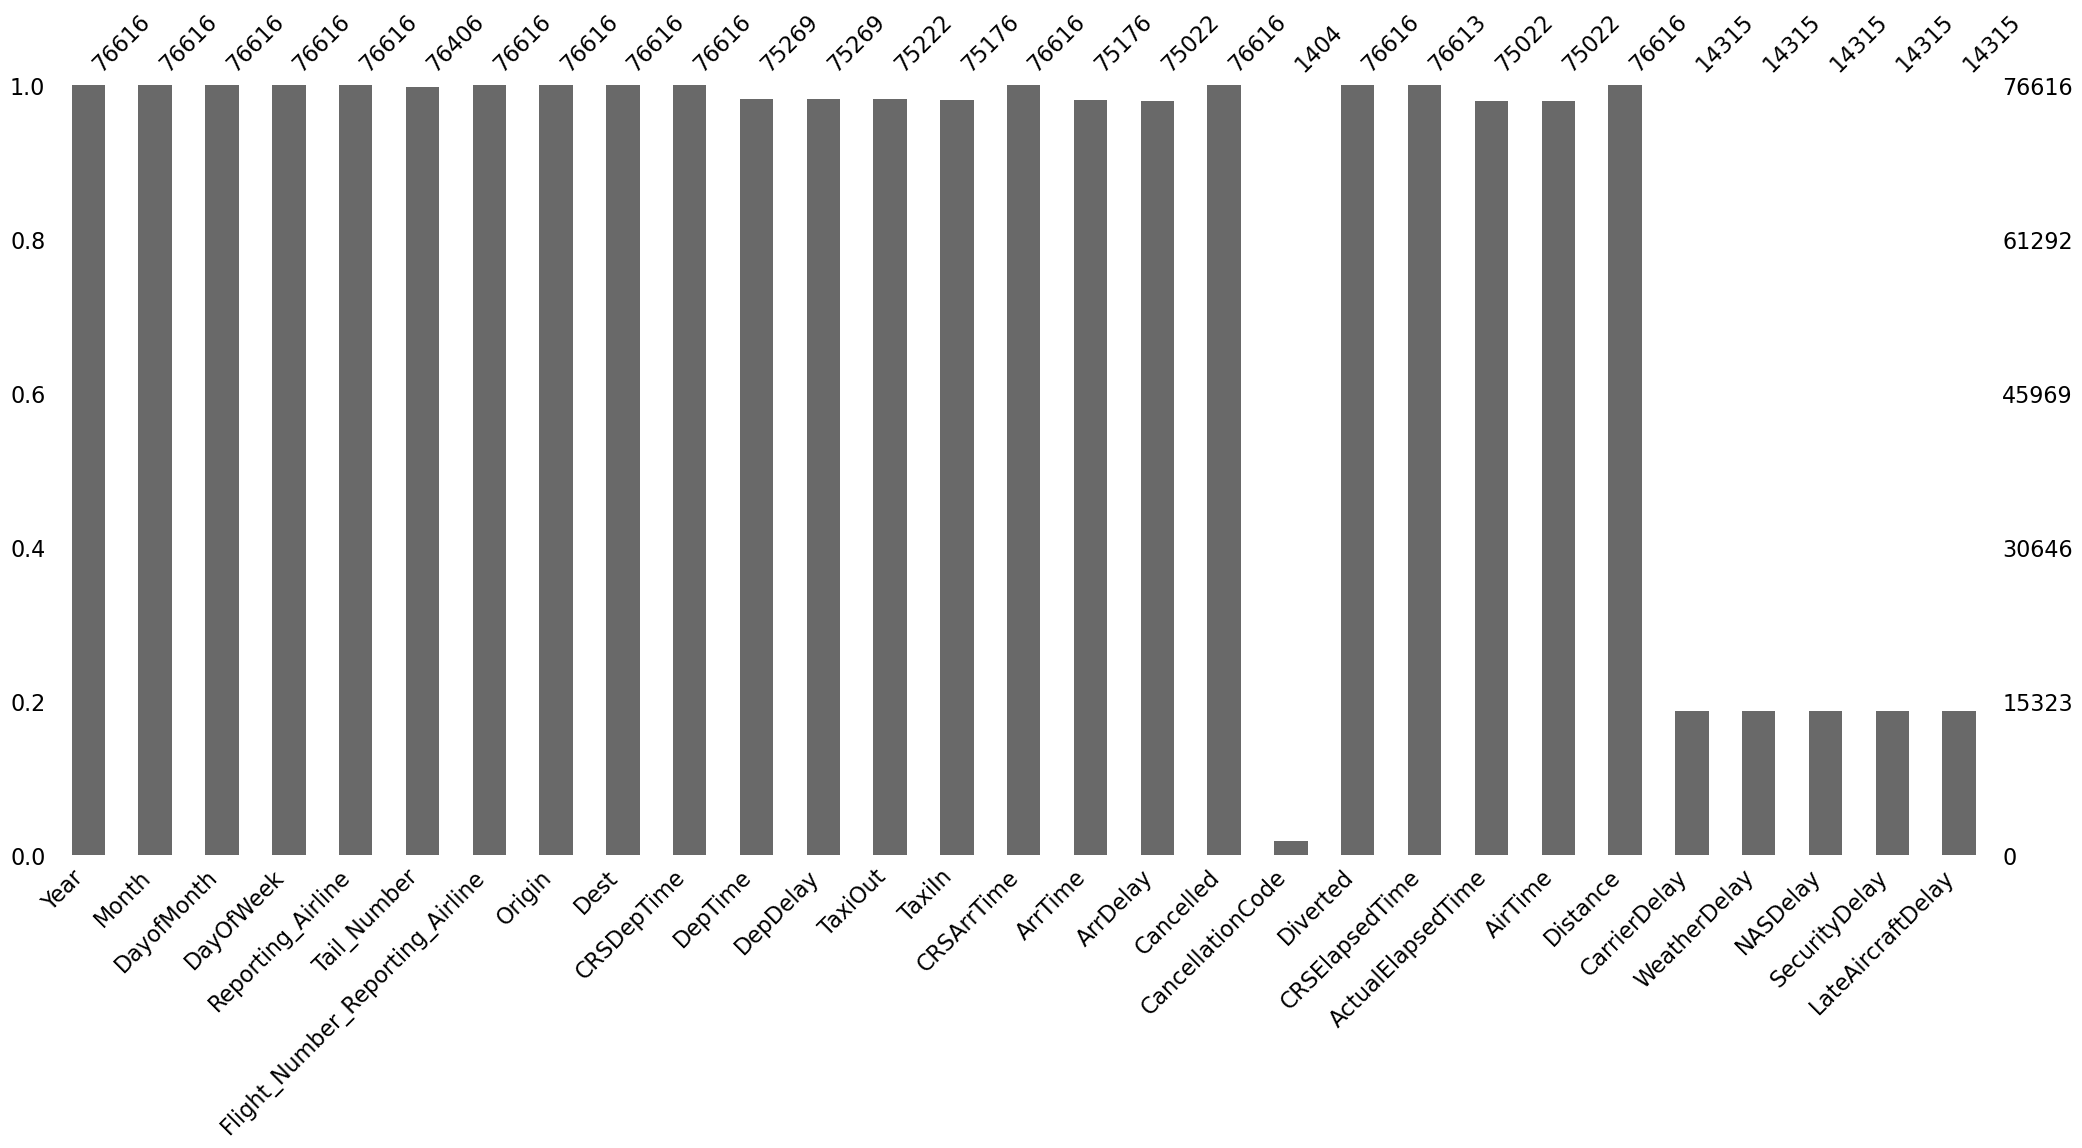

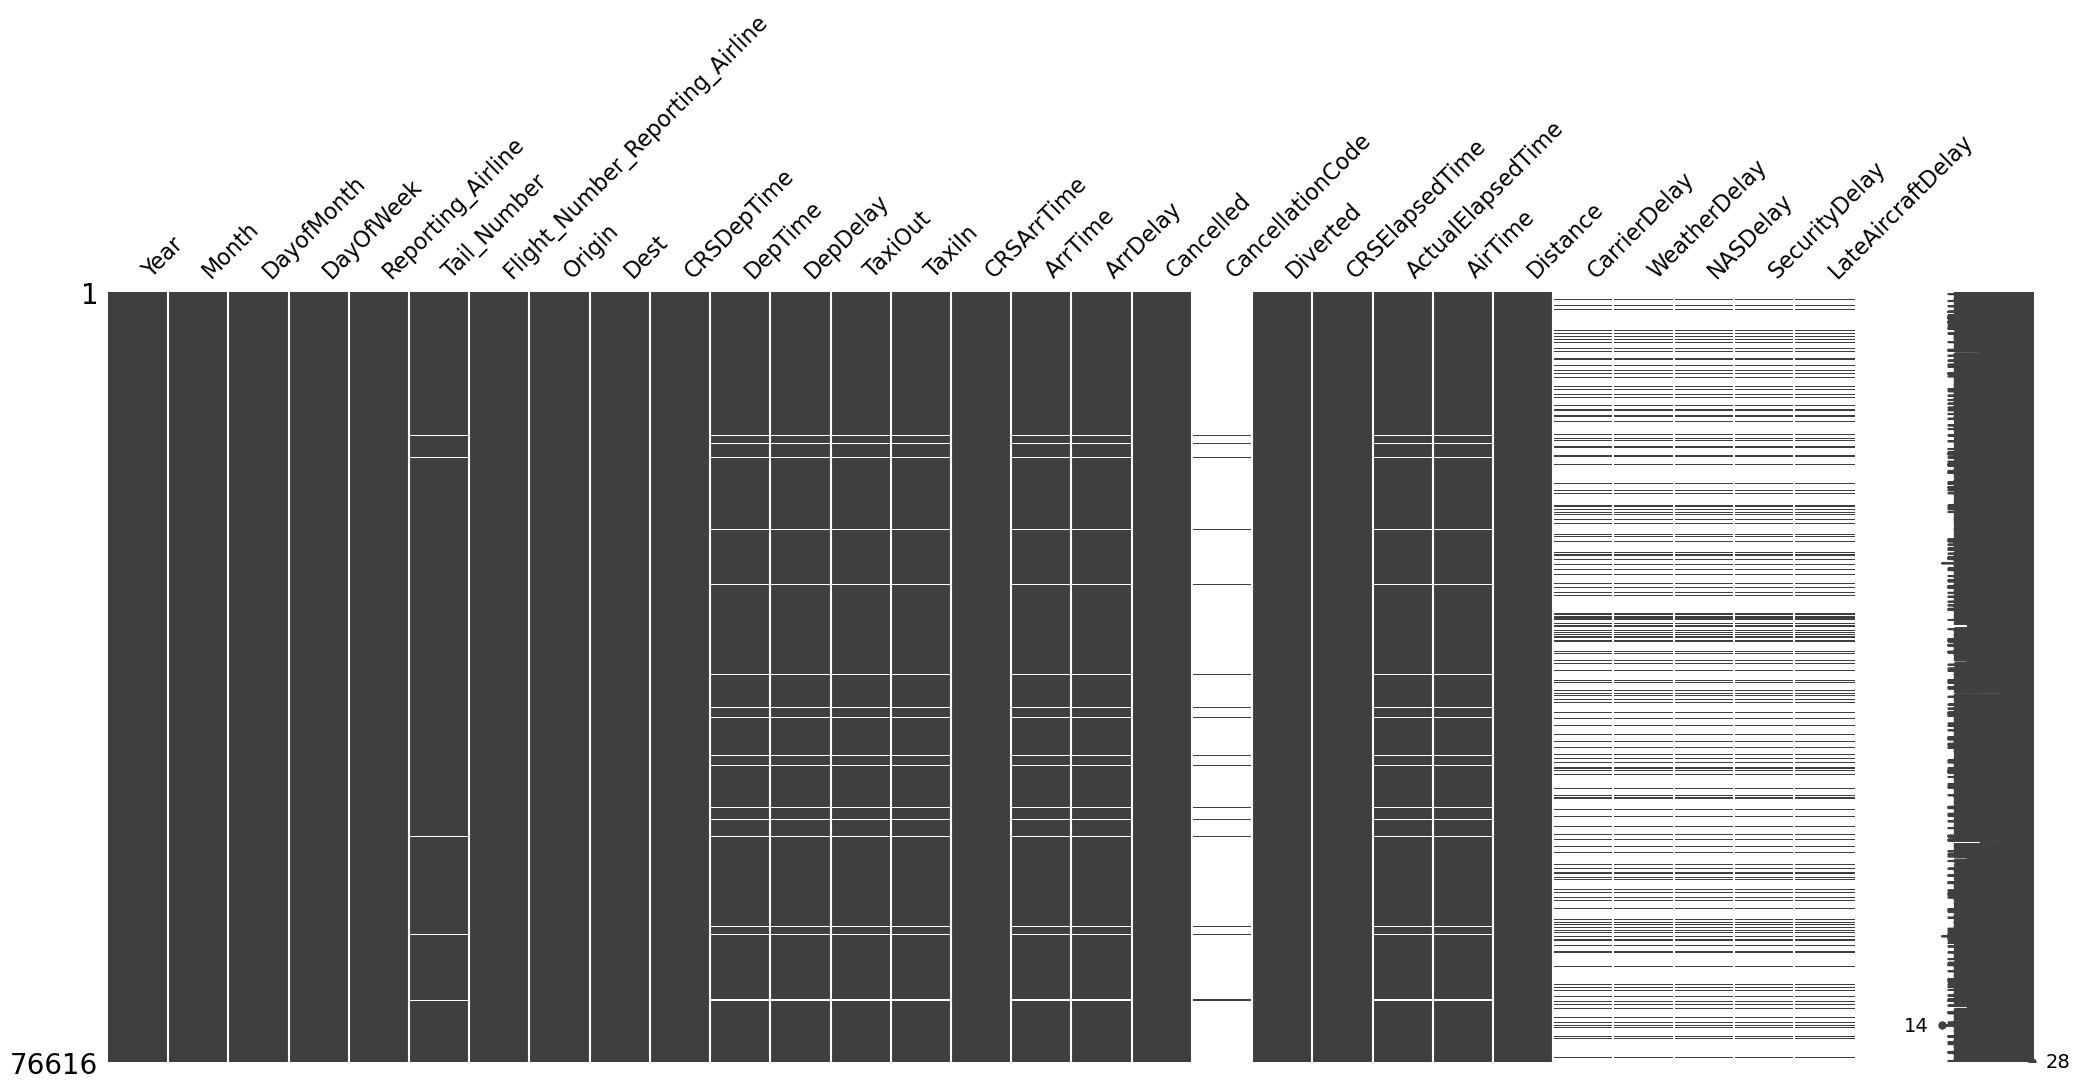

In [5]:
# visualization of available/missing data with missingno package
msno.bar(df_2019)
msno.matrix(df_2019)


### Build Holdout Mask
It a boolean mask (same shape as your dataframe) that marks a random subset of currently-observed entries to be held out / artificially treated as missing.

This performs the similar function as removing whole column data in class example. This is to enable us to compre imputed and roginal true values and calculated metrics (e.g., RMSE).

In [6]:
import numpy as np

target_col = "ActualElapsedTime"
seed = 42
missing_rate = 0.10

rng = np.random.default_rng(seed)
observed_mask = df_2019[target_col].notna()
holdout_mask = (rng.random(len(df_2019)) < missing_rate) & observed_mask

df_masked = df_2019.copy()
df_masked.loc[holdout_mask, target_col] = np.nan

holdout_mask.sum()

np.int64(7399)

In [7]:
# we define the following function to calculate RMSE of each method
# you don't need to make modifications here

def evaluate_method(label, df_imputed):
    y_true = df_2019.loc[holdout_mask, target_col].astype(float)
    y_pred = df_imputed.loc[holdout_mask, target_col].astype(float)
    valid = y_true.notna() & y_pred.notna()

    if valid.sum() == 0:
        rmse = np.nan
        corr = np.nan
    else:
        rmse = float(np.sqrt(np.mean((y_true[valid] - y_pred[valid]) ** 2)))
        corr = float(np.corrcoef(y_true[valid], y_pred[valid])[0, 1])

    return {"method": label, "rmse": rmse}

### Method 1: Simple Imputation with a constant

In [8]:
# Constant imputation
constant_fill = df_2019[target_col].median()
df_const = df_masked.copy()
df_const[target_col] = df_const[target_col].fillna(constant_fill)
df_const[target_col].isna().sum()

np.int64(0)

In [9]:
# use .describe() methods to get key statistics of the imputed column
df_const[target_col].describe()

count    76616.000000
mean       134.482562
std         68.336504
min         16.000000
25%         88.000000
50%        119.000000
75%        159.000000
max        665.000000
Name: ActualElapsedTime, dtype: float64

In [10]:
evaluate_method("Constant", df_const)

c:\Users\flowe\miniconda3\envs\de300\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
c:\Users\flowe\miniconda3\envs\de300\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide


{'method': 'Constant', 'rmse': 75.19771479448166}

### Method 2: MICE with miceforest
key function
```python
kernel = mf.ImputationKernel(
    df_masked[numeric_cols].astype(float),
    datasets=1,
    save_all_iterations=False,
    random_state=seed,
    mean_match_candidates=5,
)
kernel.mice(mice_iters)
df_mice_num = kernel.complete_data(dataset=0)
```

In [11]:
# Get a list of columns that are numeric columns
df_mice = df_masked.copy()
numeric_cols = df_2019.select_dtypes('number').columns.tolist()

In [12]:
# When building the MICE kernel, only use the dataset with numeric columns
kernel = mf.ImputationKernel(
    df_mice[numeric_cols].astype(float),
    num_datasets=1,
    save_all_iterations_data=False,
    random_state=seed,
    mean_match_candidates=5,
)

In [13]:
# run the MICE algorithm
mice_iters = 5
kernel.mice(iterations=mice_iters)

In [14]:
# use .describe() methods to get key statistics of the imputed column
df_mice = kernel.complete_data(dataset=0)
df_mice[numeric_cols].describe()

,Year,Month,DayofMonth,DayOfWeek,Flight_Number_Reporting_Airline,CRSDepTime,DepTime,DepDelay,TaxiOut,TaxiIn,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,76616.0,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,...,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000
mean,2019.0,6.573705,15.711562,3.935431,2550.772593,1331.806163,1335.541715,12.028258,17.712110,8.105957,...,0.002480,141.721351,136.319202,111.326263,799.163047,7.978843,3.500535,12.317166,1.304649,6.390297
std,0.0,3.416143,8.729497,2.000527,1798.585058,493.369923,507.753447,52.018964,10.650583,7.579120,...,0.049737,72.289220,72.183975,70.339803,592.120773,31.552403,18.364084,19.588374,4.935303,25.609518
min,2019.0,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,-42.000000,1.000000,1.000000,...,0.000000,20.000000,16.000000,8.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019.0,4.000000,8.000000,2.000000,1024.750000,915.000000,916.000000,-5.000000,11.000000,4.000000,...,0.000000,90.000000,84.000000,60.000000,368.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2019.0,7.000000,16.000000,4.000000,2147.000000,1323.000000,1329.000000,-2.000000,15.000000,6.000000,...,0.000000,124.000000,118.000000,93.000000,640.000000,0.000000,0.000000,15.000000,0.000000,0.000000
75%,2019.0,10.000000,23.000000,6.000000,3896.250000,1739.000000,1747.000000,8.000000,20.000000,9.000000,...,0.000000,171.000000,167.000000,140.000000,1032.000000,10.000000,0.000000,16.000000,0.000000,0.000000
max,2019.0,12.000000,31.000000,7.000000,7439.000000,2359.000000,2400.000000,1855.000000,168.000000,199.000000,...,1.000000,705.000000,665.000000,632.000000,5095.000000,1628.000000,1847.000000,1194.000000,180.000000,1013.000000


In [15]:
evaluate_method("mice", df_mice)

{'method': 'mice', 'rmse': 7.444210667979017}

### Method 3: KNN imputation
Key function
```python
knn_imputer = KNNImputer(n_neighbors=knn_k)
df_knn_num = pd.DataFrame(
    knn_imputer.fit_transform(df_masked[numeric_cols].astype(float)),
    columns=numeric_cols,
    index=df_masked.index,
)
```

In [27]:
df_masked[numeric_cols].astype(float)

,Year,Month,DayofMonth,DayOfWeek,Flight_Number_Reporting_Airline,CRSDepTime,DepTime,DepDelay,TaxiOut,TaxiIn,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2019.0,6.0,11.0,2.0,3459.0,1950.0,2331.0,221.0,19.0,6.0,...,0.0,67.0,60.0,35.0,192.0,0.0,0.0,0.0,0.0,214.0
1,2019.0,9.0,2.0,1.0,6104.0,1204.0,1200.0,-4.0,10.0,10.0,...,0.0,168.0,169.0,149.0,1010.0,NaN,NaN,NaN,NaN,NaN
2,2019.0,3.0,27.0,3.0,5125.0,1605.0,1605.0,0.0,21.0,4.0,...,0.0,83.0,77.0,52.0,245.0,NaN,NaN,NaN,NaN,NaN
3,2019.0,2.0,13.0,3.0,172.0,1055.0,1055.0,0.0,7.0,5.0,...,0.0,115.0,109.0,97.0,674.0,NaN,NaN,NaN,NaN,NaN
4,2019.0,5.0,8.0,3.0,1416.0,1714.0,1709.0,-5.0,13.0,8.0,...,0.0,81.0,NaN,44.0,270.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76611,2019.0,5.0,26.0,7.0,15.0,712.0,745.0,33.0,14.0,15.0,...,0.0,384.0,394.0,365.0,2586.0,33.0,0.0,10.0,0.0,0.0
76612,2019.0,8.0,12.0,1.0,5227.0,1259.0,1253.0,-6.0,20.0,11.0,...,0.0,180.0,179.0,148.0,1075.0,NaN,NaN,NaN,NaN,NaN
76613,2019.0,10.0,18.0,5.0,5513.0,1515.0,1512.0,-3.0,34.0,2.0,...,0.0,79.0,93.0,57.0,313.0,NaN,NaN,NaN,NaN,NaN
76614,2019.0,1.0,1.0,2.0,170.0,845.0,909.0,24.0,17.0,2.0,...,0.0,280.0,262.0,243.0,1740.0,NaN,NaN,NaN,NaN,NaN


In [29]:
# impute with KNN methods
knn_k = 3
knn_imputer = KNNImputer(n_neighbors=knn_k, weights='uniform')
df_knn_num = pd.DataFrame(
    knn_imputer.fit_transform(df_masked[numeric_cols].astype(float)),
    columns=numeric_cols,
    index=df_masked.index,
)

In [32]:
# print the first few lines of the dataframe with imputed values
df_knn_num.head()

,Year,Month,DayofMonth,DayOfWeek,Flight_Number_Reporting_Airline,CRSDepTime,DepTime,DepDelay,TaxiOut,TaxiIn,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2019.0,6.0,11.0,2.0,3459.0,1950.0,2331.0,221.0,19.0,6.0,...,0.0,67.0,60.000000,35.0,192.0,0.000000,0.0,0.000000,0.0,214.000000
1,2019.0,9.0,2.0,1.0,6104.0,1204.0,1200.0,-4.0,10.0,10.0,...,0.0,168.0,169.000000,149.0,1010.0,18.333333,0.0,15.000000,0.0,0.000000
2,2019.0,3.0,27.0,3.0,5125.0,1605.0,1605.0,0.0,21.0,4.0,...,0.0,83.0,77.000000,52.0,245.0,12.666667,0.0,0.000000,0.0,7.666667
3,2019.0,2.0,13.0,3.0,172.0,1055.0,1055.0,0.0,7.0,5.0,...,0.0,115.0,109.000000,97.0,674.0,5.333333,0.0,10.000000,0.0,8.333333
4,2019.0,5.0,8.0,3.0,1416.0,1714.0,1709.0,-5.0,13.0,8.0,...,0.0,81.0,61.333333,44.0,270.0,6.000000,0.0,1.333333,0.0,10.333333


In [33]:
# use .describe() methods to get key statistics of the imputed column
df_knn_num.describe()

,Year,Month,DayofMonth,DayOfWeek,Flight_Number_Reporting_Airline,CRSDepTime,DepTime,DepDelay,TaxiOut,TaxiIn,...,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,76616.0,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,...,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000,76616.000000
mean,2019.0,6.573705,15.711562,3.935431,2550.772593,1331.806163,1335.992730,11.088833,17.382562,7.754503,...,0.002480,141.721307,136.261703,111.200406,799.163047,10.901770,1.541297,12.778458,0.087040,12.152914
std,0.0,3.416143,8.729497,2.000527,1798.585058,493.369923,508.050604,50.264531,9.901418,6.288864,...,0.049737,72.289288,72.148974,70.285290,592.120773,31.879687,17.727496,20.026134,1.222684,26.392057
min,2019.0,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000,-42.000000,1.000000,1.000000,...,0.000000,20.000000,16.000000,8.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019.0,4.000000,8.000000,2.000000,1024.750000,915.000000,916.000000,-5.000000,11.000000,4.000000,...,0.000000,90.000000,83.666667,60.000000,368.000000,0.333333,0.000000,3.666667,0.000000,0.000000
50%,2019.0,7.000000,16.000000,4.000000,2147.000000,1323.000000,1329.000000,-2.000000,15.000000,6.000000,...,0.000000,124.000000,118.000000,93.000000,640.000000,6.000000,0.000000,9.666667,0.000000,6.000000
75%,2019.0,10.000000,23.000000,6.000000,3896.250000,1739.000000,1748.000000,7.000000,20.000000,9.000000,...,0.000000,171.000000,166.000000,140.000000,1032.000000,12.333333,0.000000,17.000000,0.000000,14.333333
max,2019.0,12.000000,31.000000,7.000000,7439.000000,2359.000000,2400.000000,1855.000000,168.000000,199.000000,...,1.000000,705.000000,665.000000,632.000000,5095.000000,1628.000000,1847.000000,1194.000000,180.000000,1013.000000


In [34]:
evaluate_method("knn", df_knn_num)

{'method': 'knn', 'rmse': 15.518788136037385}

## Summary/Takeaways
In practice:

- MCAR → complete-case or simple imputation often okay

- MAR → regression/likelihood-based methods can be valid; naive imputation can bias results

- MNAR → must model missingness explicitly (or do sensitivity analysis)

Imputation quality should be evaluated both by:

- predictive error (e.g., RMSE when truth is known),

- structure preservation (e.g., correlation matrix).
